In [9]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

METRICS_DF_PATH = Path("../data/processed/model_metrics.csv")
metrics_df = pd.read_csv(METRICS_DF_PATH, index_col=0)

In [10]:
# look at the metrics df
metrics_df.head()

,CV Mean F1,Test Accuracy,Precision,Recall,ROC AUC Score,F1 Score
Dummy,0.000000,0.998709,0.000000,0.000000,0.500000,0.000000
Logistic Regression,0.089368,0.973623,0.046561,0.997565,0.998189,0.088970
Random Forest,0.997712,0.999997,1.000000,0.997565,0.998769,0.998781
XG Boost,0.994982,0.999993,0.996959,0.997565,0.999159,0.997262


In [11]:
# feature importance of best model
import joblib

rand_for_pipeline = joblib.load("../outputs/models/random_forest.joblib")
rand_for_model = rand_for_pipeline.named_steps["model"]
preprocessor = rand_for_pipeline.named_steps["preprocessor"]

importances = pd.DataFrame({
    "feature": preprocessor.get_feature_names_out(),
    "importance": rand_for_model.feature_importances_,
}).sort_values("importance", ascending=False)

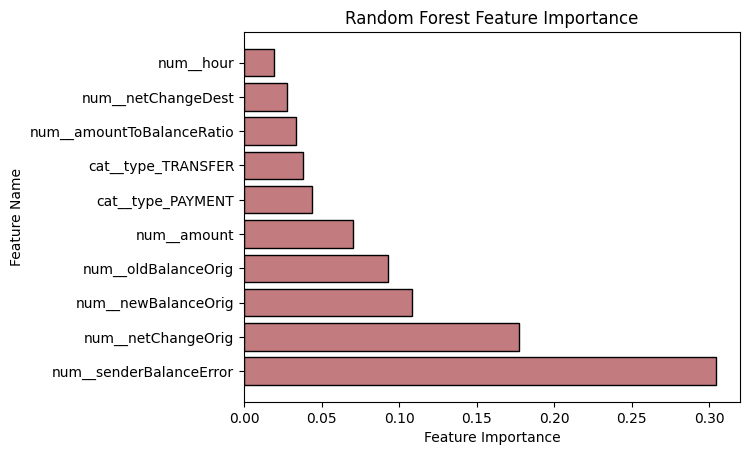

In [12]:
# plot top 10 features
top_features = importances.nlargest(10, "importance")

plt.barh(top_features.feature, top_features.importance, edgecolor="black", color="#c27b7f")
plt.xlabel("Feature Importance")
plt.ylabel("Feature Name")
plt.title("Random Forest Feature Importance")
plt.show()

## Machine Learning Conclusions

Four classification models were trained to predict fraudulent transactions. 

The Dummy Classifier demonstrated that a very high accuracy score can be achieved simply by predicting the majority class, highlighting why accuracy is not an appropriate metric for this highly imbalanced problem. Despite its high accuracy, the model failed to identify fraudulent transactions, resulting in zero precision, recall and F1 score.

Logistic Regression achieved an extremely high recall (0.998), successfully identifying almost all fraudulent transactions. However, its precision was very low (0.047), indicating a large number of false positives. 

The strongest models were Random Forest and XGBoost, both achieving exceptional performance across all evaluation metrics. Random Forest obtained the highest F1 score (0.999), reflecting an outstanding balance between precision and recall. These results suggest that fraudulent transactions in the PaySim dataset exhibit highly distinguishable patterns that can be effectively captured by tree-based ensemble methods.

Feature importance analysis from the Random Forest model revealed that “senderBalanceError” was the most influential predictor, accounting for approximately 30% of the model's importance. This finding is intuitive, as unusual sender balance behavior may indicate suspicious transaction activity. The next most important features were “netChangeOrig”, “newBalanceOrig”, and “oldBalanceOrig”, suggesting that changes in account balances and transaction amounts play a central role in distinguishing fraudulent transactions. Interestingly, several engineered features, including “senderBalanceError”, “netChangeOrig”, and “amountToBalanceRatio”, ranked among the most important predictors, indicating that feature engineering contributed meaningfully to model performance. Conversely, temporal features such as dayOfWeek and hour, as well as receiverBalanceError, had relatively little influence on the model's predictions.